--- Dataset Information ---
Shape: 271116 rows, 15 columns

--- Column Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB
None

--- First 5 Rows ---
   ID                      Name Sex   Age  Heigh

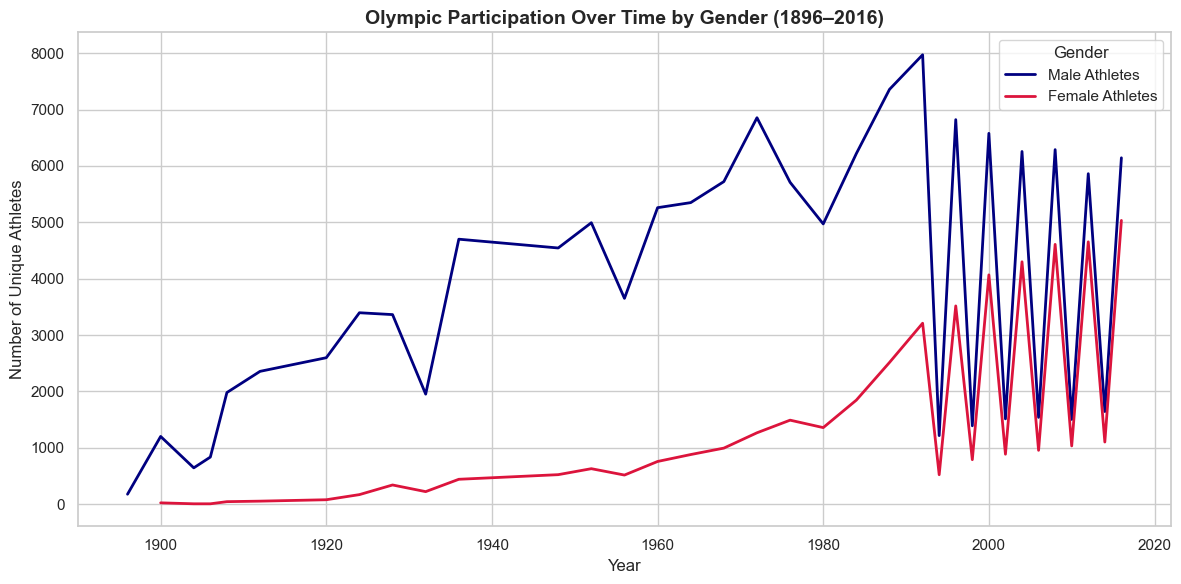

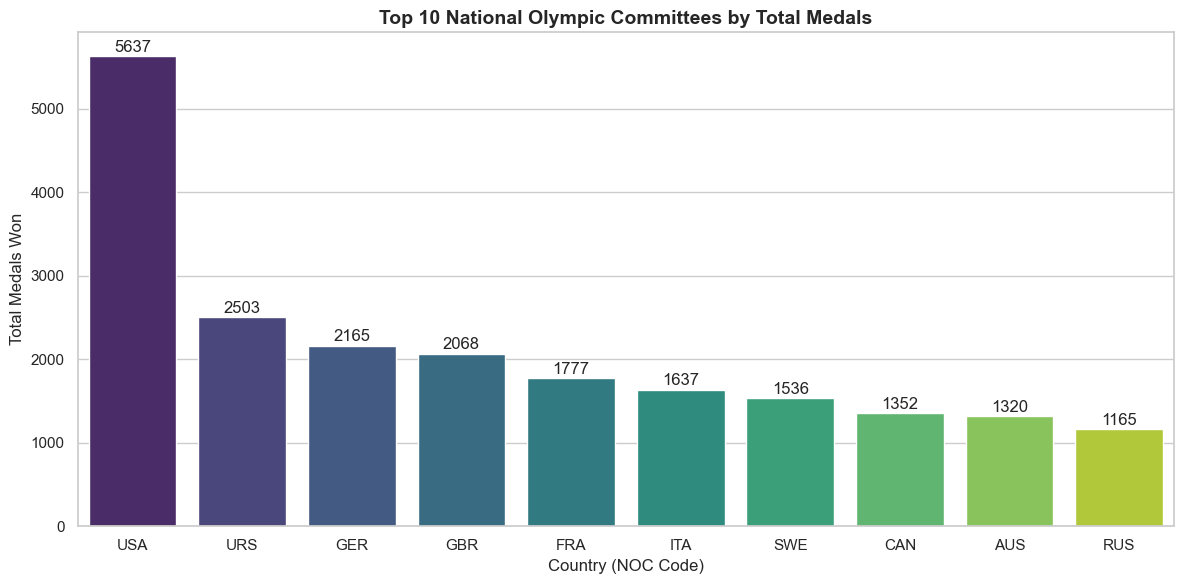

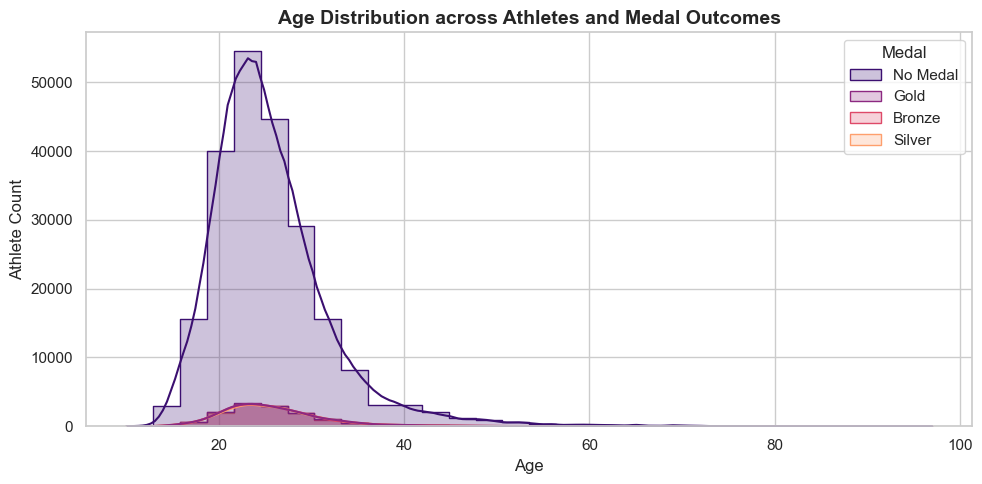

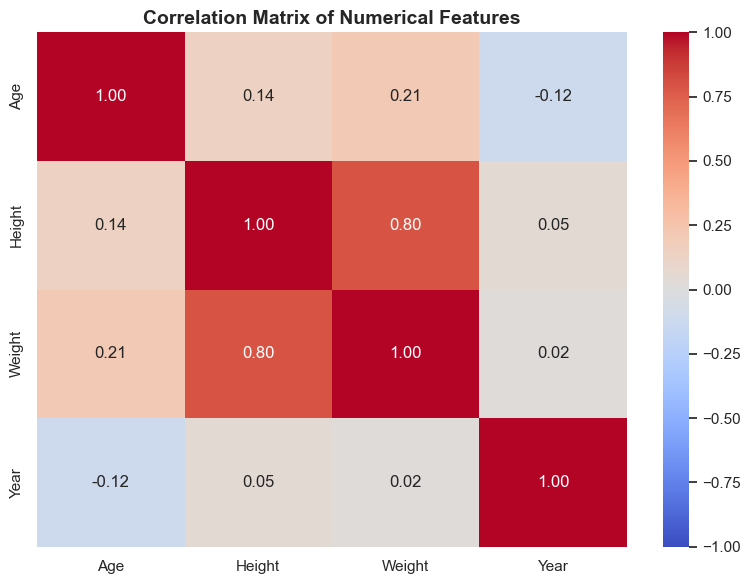


--- SUMMARY METRICS ---
Total Unique Athletes Tracked: 135,571
Total Games Editions: 51
Unique Summer Athletes: 116,776
Unique Winter Athletes: 18,958


In [2]:
# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv("athlete_data.csv")

# ==========================================
# 2. UNDERSTAND THE DATASET
# ==========================================
print("--- Dataset Information ---")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- Column Data Types & Non-Null Counts ---")
print(df.info())

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Summary Statistics (Numerical) ---")
print(df[["Age", "Height", "Weight", "Year"]].describe())

print("\n--- Summary Statistics (Categorical) ---")
print(df.describe(include=["O"]))

# ==========================================
# 3. DATA PREPROCESSING & CLEANING
# ==========================================
# Check duplicate records
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Records Found: {duplicate_count}")

# Check missing values
missing_data = pd.DataFrame(
    {
        "Missing Values": df.isnull().sum(),
        "Percentage (%)": (df.isnull().sum() / len(df)) * 100,
    }
)
print("\n--- Missing Value Analysis ---")
print(missing_data[missing_data["Missing Values"] > 0])

# Clean missing values for Medal
df["Medal"] = df["Medal"].fillna("No Medal")

# Optional: Impute physical attributes by Sport & Sex medians for EDA modeling
df["Age_Imputed"] = df.groupby(["Sport", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
df["Height_Imputed"] = df.groupby(["Sport", "Sex"])["Height"].transform(
    lambda x: x.fillna(x.median())
)
df["Weight_Imputed"] = df.groupby(["Sport", "Sex"])["Weight"].transform(
    lambda x: x.fillna(x.median())
)

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS & VISUALIZATIONS
# ==========================================

# Chart 1: Gender Participation Trend Over Time
plt.figure(figsize=(12, 6))
gender_trend = df.groupby(["Year", "Sex"])["ID"].nunique().unstack()
plt.plot(
    gender_trend.index,
    gender_trend["M"],
    label="Male Athletes",
    color="navy",
    linewidth=2,
)
plt.plot(
    gender_trend.index,
    gender_trend["F"],
    label="Female Athletes",
    color="crimson",
    linewidth=2,
)
plt.title(
    "Olympic Participation Over Time by Gender (1896–2016)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Unique Athletes", fontsize=12)
plt.legend(title="Gender")
plt.tight_layout()
plt.savefig("gender_trend.png")
plt.show()

# Chart 2: Top 10 Medal-Winning Nations
plt.figure(figsize=(12, 6))
top_nocs = (
    df[df["Medal"] != "No Medal"]["NOC"]
    .value_counts()
    .head(10)
    .reset_index(name="Medal_Count")
)
sns.barplot(
    data=top_nocs, x="NOC", y="Medal_Count", palette="viridis", hue="NOC"
)
plt.title("Top 10 National Olympic Committees by Total Medals", fontsize=14, fontweight="bold")
plt.xlabel("Country (NOC Code)", fontsize=12)
plt.ylabel("Total Medals Won", fontsize=12)
for idx, row in top_nocs.iterrows():
    plt.text(idx, row["Medal_Count"] + 50, str(row["Medal_Count"]), ha="center")
plt.tight_layout()
plt.savefig("top_nocs.png")
plt.show()

# Chart 3: Age Distribution of Medalists vs Non-Medalists
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Age",
    hue="Medal",
    bins=30,
    kde=True,
    palette="magma",
    element="step",
)
plt.title(
    "Age Distribution across Athletes and Medal Outcomes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Athlete Count", fontsize=12)
plt.tight_layout()
plt.savefig("age_distribution.png")
plt.show()

# Chart 4: Correlation Matrix of Physical Characteristics
plt.figure(figsize=(8, 6))
corr_matrix = df[["Age", "Height", "Weight", "Year"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

# ==========================================
# 5. KEY DERIVED INSIGHTS
# ==========================================
total_athletes = df["ID"].nunique()
total_editions = df["Games"].nunique()
summer_count = df[df["Season"] == "Summer"]["ID"].nunique()
winter_count = df[df["Season"] == "Winter"]["ID"].nunique()

print("\n--- SUMMARY METRICS ---")
print(f"Total Unique Athletes Tracked: {total_athletes:,}")
print(f"Total Games Editions: {total_editions}")
print(f"Unique Summer Athletes: {summer_count:,}")
print(f"Unique Winter Athletes: {winter_count:,}")